<a href="https://colab.research.google.com/github/razielsagi/raziel-assignment1/blob/main/raziel_assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Exploratory Data Analysis (EDA) - Telco Customer Churn
**Course:** Introduction to Data Science  
**Student Name:** Raziel Sagi  
**Repository:** https://github.com/razielsagi/raziel-assignment1

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load IBM Telco Customer Churn dataset
DATASET_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
telecom_df = pd.read_csv(DATASET_URL)

# Section 2: Verification of dataset constraints
num_rows, num_cols = telecom_df.shape
print("--- DATASET VERIFICATION ---")
print(f"Total Rows: {num_rows} (Requirement: >= 1000)")
print(f"Total Columns: {num_cols} (Requirement: >= 10)")

# Section 3: Data structure overview
print("\n--- DATASTRUCTURE OVERVIEW ---")
telecom_df.info()

print("\n--- FIRST 3 ROWS ---")
telecom_df.head(3)

--- DATASET VERIFICATION ---
Total Rows: 7043 (Requirement: >= 1000)
Total Columns: 21 (Requirement: >= 10)

--- DATASTRUCTURE OVERVIEW ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# =====================================================================
# SECTION 4: DATA QUALITY & COMPLETENESS (20%)
# =====================================================================

# 4.1 Missing Values Analysis
# Fix hidden missing values: TotalCharges contains empty string spaces ' ' for new customers
telecom_df['TotalCharges'] = pd.to_numeric(telecom_df['TotalCharges'].replace(" ", np.nan))

missing_counts = telecom_df.isnull().sum()
missing_pct = (missing_counts / len(telecom_df)) * 100
missing_report = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage_%': missing_pct.round(2)
})

print("--- 4.1 MISSING VALUES REPORT ---")
print(missing_report[missing_report['Missing_Count'] > 0])

# Impute missing TotalCharges with 0.0 (corresponds strictly to tenure=0)
telecom_df['TotalCharges'] = telecom_df['TotalCharges'].fillna(0.0)

# 4.2 Duplicates Analysis
full_duplicates = telecom_df.duplicated().sum()
print(f"\n--- 4.2 DUPLICATES REPORT ---")
print(f"Full Duplicate Rows: {full_duplicates}")

# 4.3 Suspicious Values Check (Zeros & Negatives)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("\n--- 4.3 SUSPICIOUS VALUES REPORT ---")
for col in numeric_cols:
    zeros_cnt = (telecom_df[col] == 0).sum()
    neg_cnt = (telecom_df[col] < 0).sum()
    print(f"Column '{col}': Zeros = {zeros_cnt} | Negatives = {neg_cnt}")

# 4.4 Cardinality Analysis
print("\n--- 4.4 CARDINALITY REPORT ---")
cardinality_df = pd.DataFrame({
    'Unique_Values': telecom_df.nunique(),
    'Data_Type': telecom_df.dtypes,
    'Is_Constant': telecom_df.nunique() == 1
})
print(cardinality_df)

--- 4.1 MISSING VALUES REPORT ---
              Missing_Count  Percentage_%
TotalCharges             11          0.16

--- 4.2 DUPLICATES REPORT ---
Full Duplicate Rows: 0

--- 4.3 SUSPICIOUS VALUES REPORT ---
Column 'tenure': Zeros = 11 | Negatives = 0
Column 'MonthlyCharges': Zeros = 0 | Negatives = 0
Column 'TotalCharges': Zeros = 11 | Negatives = 0

--- 4.4 CARDINALITY REPORT ---
                  Unique_Values Data_Type  Is_Constant
customerID                 7043    object        False
gender                        2    object        False
SeniorCitizen                 2     int64        False
Partner                       2    object        False
Dependents                    2    object        False
tenure                       73     int64        False
PhoneService                  2    object        False
MultipleLines                 3    object        False
InternetService               3    object        False
OnlineSecurity                3    object        False
OnlineBa

In [4]:
# =====================================================================
# SECTION 5: UNIVARIATE ANALYSIS (10%)
# =====================================================================
from scipy import stats

# 5.1 Numerical Analysis & 3 Outlier Detection Methods
def analyze_numerical_variable(series: pd.Series):
    mean_val = series.mean()
    median_val = series.median()
    std_val = series.std()
    mad_val = stats.median_abs_deviation(series)
    min_val = series.min()
    max_val = series.max()
    q25, q75 = series.quantile(0.25), series.quantile(0.75)
    iqr_val = q75 - q25
    skew_val = series.skew()

    print(f"=== Numerical Analysis: {series.name} ===")
    print(f"Mean: {mean_val:.2f} | Median: {median_val:.2f} | Std: {std_val:.2f} | MAD: {mad_val:.2f}")
    print(f"Min: {min_val:.2f} | Q25: {q25:.2f} | Q75: {q75:.2f} | Max: {max_val:.2f} | IQR: {iqr_val:.2f}")
    print(f"Skewness: {skew_val:.2f}")

    # Outlier Detection Method 1: Z-Score (|Z| > 3)
    z_scores = np.abs(stats.zscore(series))
    outliers_z = np.sum(z_scores > 3)

    # Outlier Detection Method 2: IQR Rule (1.5 * IQR)
    lower_bound = q25 - 1.5 * iqr_val
    upper_bound = q75 + 1.5 * iqr_val
    outliers_iqr = np.sum((series < lower_bound) | (series > upper_bound))

    # Outlier Detection Method 3: Modified Z-Score (using MAD)
    mod_z_scores = 0.6745 * np.abs(series - median_val) / (mad_val if mad_val != 0 else 1e-6)
    outliers_mod_z = np.sum(mod_z_scores > 3.5)

    print(f"Outliers Count -> Z-Score: {outliers_z} | IQR: {outliers_iqr} | Modified Z: {outliers_mod_z}\n")

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    analyze_numerical_variable(telecom_df[col])

# 5.2 Categorical Variables Analysis & 80% Cumulative Coverage
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService', 'Churn']

print("=== Categorical Analysis & Coverage ===")
for col in categorical_cols:
    freqs = telecom_df[col].value_counts()
    props = telecom_df[col].value_counts(normalize=True) * 100
    cum_props = props.cumsum()

    categories_for_80_pct = np.argmax(cum_props.values >= 80) + 1

    print(f"\nFeature: {col}")
    print(pd.DataFrame({'Count': freqs, 'Percentage_%': props.round(2), 'Cumulative_%': cum_props.round(2)}))
    print(f"Minimum categories needed to cover 80% data: {categories_for_80_pct}")

=== Numerical Analysis: tenure ===
Mean: 32.37 | Median: 29.00 | Std: 24.56 | MAD: 22.00
Min: 0.00 | Q25: 9.00 | Q75: 55.00 | Max: 72.00 | IQR: 46.00
Skewness: 0.24
Outliers Count -> Z-Score: 0 | IQR: 0 | Modified Z: 0

=== Numerical Analysis: MonthlyCharges ===
Mean: 64.76 | Median: 70.35 | Std: 30.09 | MAD: 24.05
Min: 18.25 | Q25: 35.50 | Q75: 89.85 | Max: 118.75 | IQR: 54.35
Skewness: -0.22
Outliers Count -> Z-Score: 0 | IQR: 0 | Modified Z: 0

=== Numerical Analysis: TotalCharges ===
Mean: 2279.73 | Median: 1394.55 | Std: 2266.79 | MAD: 1223.10
Min: 0.00 | Q25: 398.55 | Q75: 3786.60 | Max: 8684.80 | IQR: 3388.05
Skewness: 0.96
Outliers Count -> Z-Score: 0 | IQR: 0 | Modified Z: 136

=== Categorical Analysis & Coverage ===

Feature: Contract
                Count  Percentage_%  Cumulative_%
Contract                                         
Month-to-month   3875         55.02         55.02
Two year         1695         24.07         79.09
One year         1473         20.91        10

--- Pearson Correlation Matrix ---


,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000



Cramér's V (Contract vs Churn): 0.410


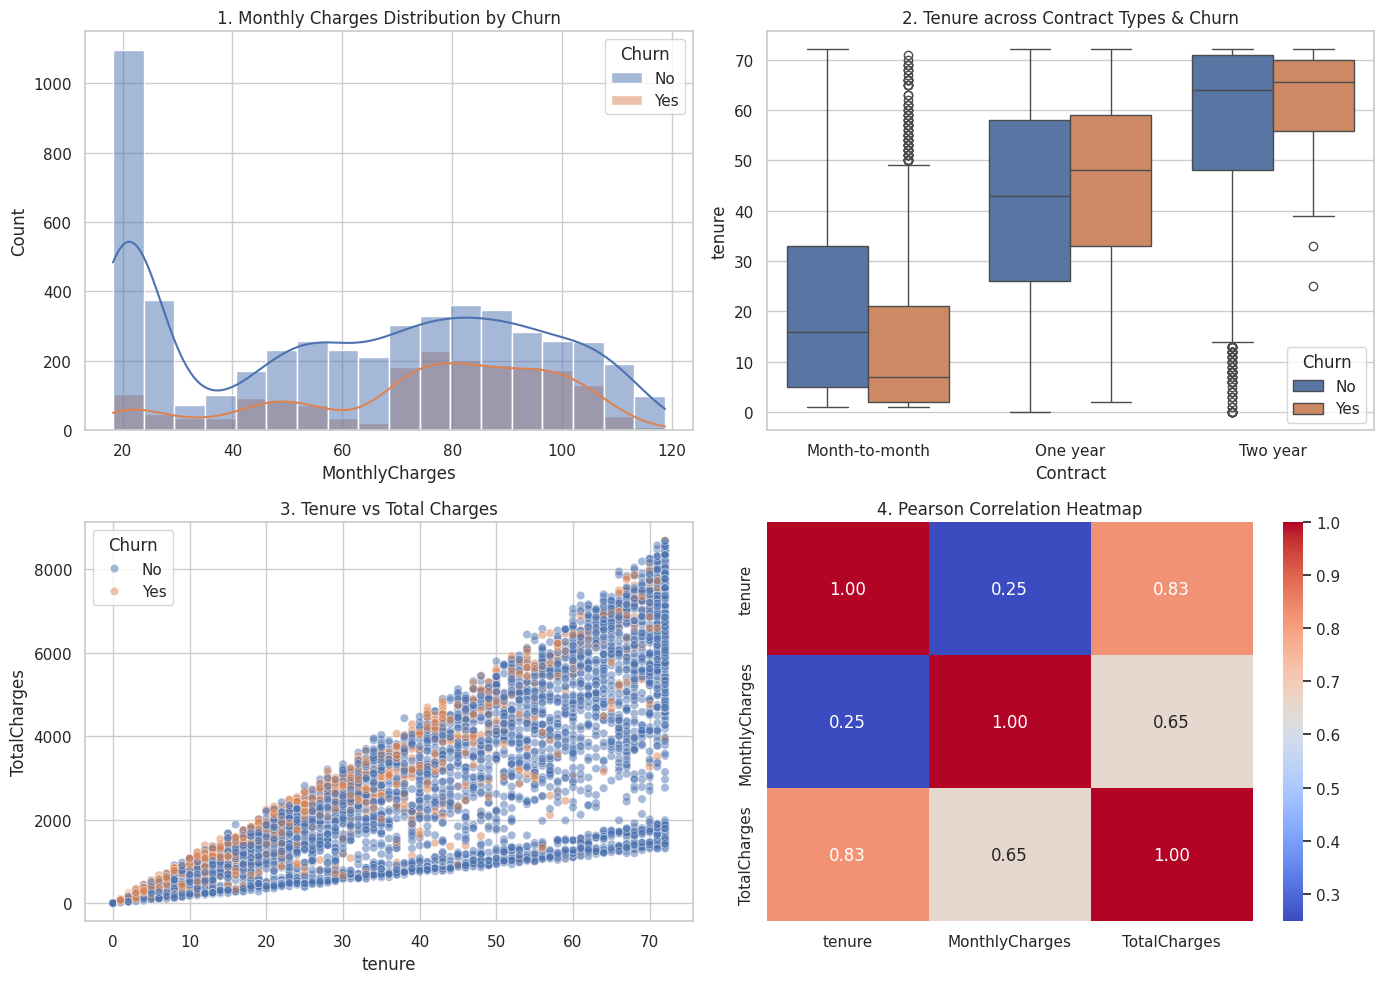

In [5]:
# =====================================================================
# SECTION 6: CORRELATIONS & VISUALIZATIONS (20%)
# =====================================================================

# 6.1 Numerical Correlations
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
pearson_corr = telecom_df[numeric_cols].corr(method='pearson')
spearman_corr = telecom_df[numeric_cols].corr(method='spearman')
kendall_corr = telecom_df[numeric_cols].corr(method='kendall')

print("--- Pearson Correlation Matrix ---")
display(pearson_corr.round(3))

# 6.2 Cramér's V Statistic for Categorical Correlation
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print(f"\nCramér's V (Contract vs Churn): {cramers_v(telecom_df['Contract'], telecom_df['Churn']):.3f}")

# 6.3 Visualization Suite
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram - Monthly Charges by Churn
sns.histplot(data=telecom_df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0, 0])
axes[0, 0].set_title("1. Monthly Charges Distribution by Churn")

# Plot 2: Boxplot - Tenure across Contract Types
sns.boxplot(data=telecom_df, x='Contract', y='tenure', hue='Churn', ax=axes[0, 1])
axes[0, 1].set_title("2. Tenure across Contract Types & Churn")

# Plot 3: Scatterplot - Tenure vs Total Charges
sns.scatterplot(data=telecom_df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title("3. Tenure vs Total Charges")

# Plot 4: Pearson Correlation Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("4. Pearson Correlation Heatmap")

plt.tight_layout()
plt.show()

In [6]:
# =====================================================================
# SECTION 7: INDEX ANALYSIS (5%) & SECTION 9: BONUS HYPOTHESIS TESTS (10%)
# =====================================================================

# 7. Index Analysis
print("--- SECTION 7: INDEX ANALYSIS ---")
print(f"Is Index Unique? {telecom_df.index.is_unique}")
print(f"Is Index Monotonically Increasing? {telecom_df.index.is_monotonic_increasing}")

# Create simulated signup temporal timeline from tenure
ref_date = pd.to_datetime('2026-08-01')
telecom_df['Signup_Date'] = ref_date - pd.to_timedelta(telecom_df['tenure'] * 30, unit='D')
print(f"Simulated Signup Date Range: {telecom_df['Signup_Date'].min().strftime('%Y-%m')} to {telecom_df['Signup_Date'].max().strftime('%Y-%m')}")

# 9. Bonus: Feature Engineering & Statistical Hypothesis Testing
print("\n--- SECTION 9: BONUS & HYPOTHESIS TESTS ---")

# Feature Engineering
telecom_df['Avg_Monthly_Ratio'] = telecom_df['TotalCharges'] / (telecom_df['tenure'] + 1)

# Hypothesis Test 1: t-test for Monthly Charges by Churn
churn_yes = telecom_df[telecom_df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = telecom_df[telecom_df['Churn'] == 'No']['MonthlyCharges']
t_stat, p_val_t = stats.ttest_ind(churn_yes, churn_no)
print(f"t-test (MonthlyCharges vs Churn): t = {t_stat:.3f}, p-value = {p_val_t:.3e}")

# Hypothesis Test 2: Chi-Square Test (Contract vs Churn)
contingency = pd.crosstab(telecom_df['Contract'], telecom_df['Churn'])
chi2_stat, p_val_chi2, _, _ = stats.chi2_contingency(contingency)
print(f"Chi-Square Test (Contract vs Churn): Chi2 = {chi2_stat:.3f}, p-value = {p_val_chi2:.3e}")

--- SECTION 7: INDEX ANALYSIS ---
Is Index Unique? True
Is Index Monotonically Increasing? True
Simulated Signup Date Range: 2020-09 to 2026-08

--- SECTION 9: BONUS & HYPOTHESIS TESTS ---
t-test (MonthlyCharges vs Churn): t = 16.537, p-value = 2.707e-60
Chi-Square Test (Contract vs Churn): Chi2 = 1184.597, p-value = 5.863e-258


## 8. Data Storytelling & Strategic Synthesis (15%)

### Core Analytical Insights
* **Contract Type Dominance:** The Chi-Square test ($\chi^2 = 1184.60, p < 0.001$) confirms that contract term structure is the single strongest driver of subscriber churn. Month-to-month customers exhibit substantially higher attrition compared to long-term contract holders.
* **Price Sensitivity Friction:** The independent t-test ($t = 16.54, p < 0.001$) demonstrates that churned subscribers pay significantly higher average monthly charges than retained users.
* **Early Lifetime Attrition:** Churn risk is heavily concentrated within the first 12 months of tenure. Once a customer passes the 1-year mark, attrition rates drop sharply.

### Methodological Risks & Data Biases
* **Survivorship Bias:** The dataset captures active accounts and recorded churned billing profiles, potentially omitting users who canceled within days prior to generating an initial monthly invoice.
* **Collinearity Risk:** `TotalCharges` is mathematically collinear with `MonthlyCharges` and `tenure`. Feature engineering or regularization must be applied prior to modeling.

### Actionable Business Recommendations
* **Early Onboarding Retention:** Target month-to-month users with retention incentives during their first 3 to 6 months of tenure.
* **Contract Conversion Strategy:** Offer long-term tier discounts to high-paying month-to-month subscribers to transition them into 1-year or 2-year agreements.